In [1]:
import pandas as pd
from pathlib import Path

In [2]:
RAW_DATA_DIR = Path("../data/raw")

TRAIN_PATH = RAW_DATA_DIR / "train_FD004.txt"
TEST_PATH = RAW_DATA_DIR / "test_FD004.txt"
TEST_RUL_PATH = RAW_DATA_DIR / "RUL_FD004.txt"

In [3]:
column_names = (
    ["engine_id", "cycle"]
    + ["setting_1", "setting_2", "setting_3"]
    + [f"sensor_{i}" for i in range(1, 22)]
)

In [4]:
train_fd004 = pd.read_csv(
    TRAIN_PATH,
    sep=r"\s+",
    header=None,
    names=column_names,
)

test_fd004 = pd.read_csv(
    TEST_PATH,
    sep=r"\s+",
    header=None,
    names=column_names,
)

rul_fd004 = pd.read_csv(
    TEST_RUL_PATH,
    sep=r"\s+",
    header=None,
    names=["rul"],
)



In [5]:


print("FD004 train shape:", train_fd004.shape)
print("FD004 test shape:", test_fd004.shape)
print("FD004 RUL shape:", rul_fd004.shape)

print()
print(
    "Train engines:",
    train_fd004["engine_id"].nunique()
)

print(
    "Test engines:",
    test_fd004["engine_id"].nunique()
)


FD004 train shape: (61249, 26)
FD004 test shape: (41214, 26)
FD004 RUL shape: (248, 1)

Train engines: 249
Test engines: 248


In [6]:
train_fd004.head()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,42.0049,0.8400,100.0,445.00,549.68,1343.43,1112.93,3.91,...,129.78,2387.99,8074.83,9.3335,0.02,330,2212,100.00,10.62,6.3670
1,1,2,20.0020,0.7002,100.0,491.19,606.07,1477.61,1237.50,9.35,...,312.59,2387.73,8046.13,9.1913,0.02,361,2324,100.00,24.37,14.6552
2,1,3,42.0038,0.8409,100.0,445.00,548.95,1343.12,1117.05,3.91,...,129.62,2387.97,8066.62,9.4007,0.02,329,2212,100.00,10.48,6.4213
3,1,4,42.0000,0.8400,100.0,445.00,548.70,1341.24,1118.03,3.91,...,129.80,2388.02,8076.05,9.3369,0.02,328,2212,100.00,10.54,6.4176
4,1,5,25.0063,0.6207,60.0,462.54,536.10,1255.23,1033.59,7.05,...,164.11,2028.08,7865.80,10.8366,0.02,305,1915,84.93,14.03,8.6754


In [7]:
train_fd004.nunique()

engine_id      249
cycle          543
setting_1      536
setting_2      105
setting_3        2
sensor_1         6
sensor_2      1704
sensor_3     13558
sensor_4     17353
sensor_5         6
sensor_6        46
sensor_7      5926
sensor_8      1038
sensor_9     25297
sensor_10       21
sensor_11      737
sensor_12     5627
sensor_13      483
sensor_14    15938
sensor_15    11915
sensor_16        2
sensor_17       54
sensor_18        6
sensor_19        2
sensor_20      652
sensor_21    21574
dtype: int64

In [8]:
train_fd004[
    ["setting_1", "setting_2", "setting_3"]
].describe()

,setting_1,setting_2,setting_3
count,61249.000000,61249.000000,61249.000000
mean,23.999823,0.571347,94.031576
std,14.780722,0.310703,14.251954
min,0.000000,0.000000,60.000000
25%,10.004600,0.250700,100.000000
50%,25.001400,0.700000,100.000000
75%,41.998100,0.840000,100.000000
max,42.008000,0.842000,100.000000


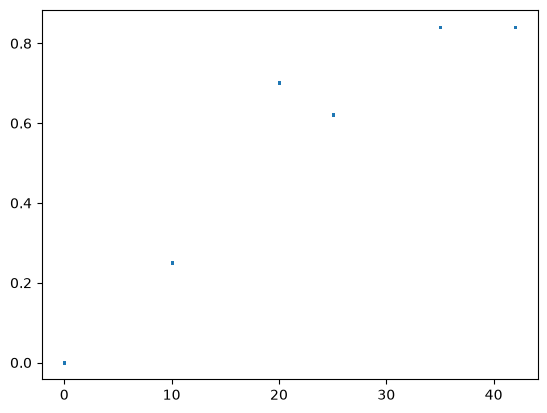

In [9]:
import matplotlib.pyplot as plt
plt.scatter(train_fd004['setting_1'], train_fd004['setting_2'], s=.2)

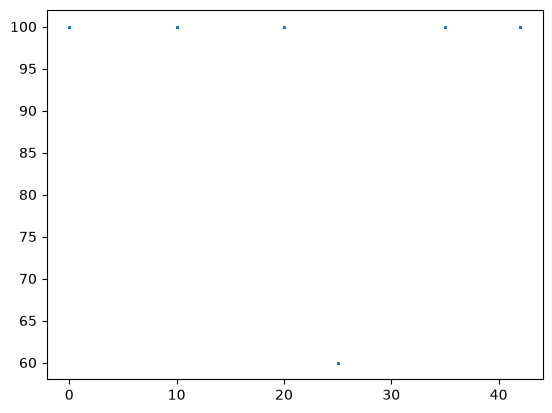

In [10]:
plt.scatter(train_fd004['setting_1'], train_fd004['setting_3'], s=.2)


In [11]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

settings = train_fd004[
    ["setting_1", "setting_2", "setting_3"]
].copy()

settings_scaler = StandardScaler()

settings_scaled = settings_scaler.fit_transform(
    settings
)

kmeans = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=20,
)

train_fd004["operating_condition"] = (
    kmeans.fit_predict(settings_scaled)
)

print(
    train_fd004["operating_condition"]
    .value_counts()
    .sort_index()
)

print()
print(
    train_fd004.groupby("operating_condition")[
        ["setting_1", "setting_2", "setting_3"]
    ].mean()
)

operating_condition
0    15395
1     9224
2     9139
3     9091
4     9238
5     9162
Name: count, dtype: int64

                     setting_1  setting_2  setting_3
operating_condition                                 
0                    42.002987   0.840495      100.0
1                    10.002990   0.250503      100.0
2                    25.003053   0.620504       60.0
3                    20.002974   0.700505      100.0
4                     0.001508   0.000495      100.0
5                    35.003029   0.840506      100.0


In [12]:
train_fd004

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,operating_condition
0,1,1,42.0049,0.8400,100.0,445.00,549.68,1343.43,1112.93,3.91,...,2387.99,8074.83,9.3335,0.02,330,2212,100.00,10.62,6.3670,0
1,1,2,20.0020,0.7002,100.0,491.19,606.07,1477.61,1237.50,9.35,...,2387.73,8046.13,9.1913,0.02,361,2324,100.00,24.37,14.6552,3
2,1,3,42.0038,0.8409,100.0,445.00,548.95,1343.12,1117.05,3.91,...,2387.97,8066.62,9.4007,0.02,329,2212,100.00,10.48,6.4213,0
3,1,4,42.0000,0.8400,100.0,445.00,548.70,1341.24,1118.03,3.91,...,2388.02,8076.05,9.3369,0.02,328,2212,100.00,10.54,6.4176,0
4,1,5,25.0063,0.6207,60.0,462.54,536.10,1255.23,1033.59,7.05,...,2028.08,7865.80,10.8366,0.02,305,1915,84.93,14.03,8.6754,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61244,249,251,9.9998,0.2500,100.0,489.05,605.33,1516.36,1315.28,10.52,...,2388.73,8185.69,8.4541,0.03,372,2319,100.00,29.11,17.5234,1
61245,249,252,0.0028,0.0015,100.0,518.67,643.42,1598.92,1426.77,14.62,...,2388.46,8185.47,8.2221,0.03,396,2388,100.00,39.38,23.7151,4
61246,249,253,0.0029,0.0000,100.0,518.67,643.68,1607.72,1430.56,14.62,...,2388.48,8193.94,8.2525,0.03,395,2388,100.00,39.78,23.8270,4
61247,249,254,35.0046,0.8400,100.0,449.44,555.77,1381.29,1148.18,5.48,...,2388.83,8125.64,9.0515,0.02,337,2223,100.00,15.26,9.0774,5


In [13]:
# We need to see sensor readings in these different operating conditions to 
# determine wether to scale globally or by operation_condition 

sensor_columns = [
    col
    for col in train_fd004.columns
    if col.startswith("sensor_")
]

condition_sensor_means = (
    train_fd004
    .groupby("operating_condition")[sensor_columns]
    .mean()
)

condition_sensor_means

,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
operating_condition,,,,,,,,,,,,,,,,,,,,,
0,445.00,549.477912,1352.562715,1124.490963,3.91,5.708030,138.928309,2212.005179,8327.564196,1.022520,...,130.824420,2388.089554,8090.707893,9.331878,0.020000,330.543813,2212.0,100.00,10.622848,6.372698
1,489.05,604.700575,1500.003491,1307.423831,10.52,15.482330,395.403328,2318.940497,8785.888140,1.260671,...,372.446648,2388.143264,8136.946143,8.621487,0.029996,369.188855,2319.0,100.00,28.636645,17.181134
2,462.54,536.738590,1260.672766,1046.772438,7.05,9.018245,175.764793,1915.411832,8014.089201,0.939716,...,164.877458,2028.310378,7877.958259,10.864516,0.020000,306.824926,1915.0,84.93,14.310108,8.587196
3,491.19,607.326724,1483.501860,1249.568890,9.35,13.639413,335.213732,2324.000843,8729.255494,1.078040,...,315.532601,2388.132323,8066.973056,9.190516,0.021609,364.825872,2324.0,100.00,24.533805,14.721140
4,518.67,642.496738,1588.519059,1405.249438,14.62,21.599282,555.114113,2388.084244,9063.492293,1.301242,...,523.031886,2388.084030,8143.464681,8.400411,0.030000,392.673306,2388.0,100.00,38.976661,23.388880
5,449.44,555.564542,1364.709756,1128.238337,5.48,7.990692,194.903643,2223.040970,8355.912172,1.023427,...,183.443833,2388.138346,8073.665918,9.288397,0.020000,333.727680,2223.0,100.00,14.882462,8.929792


In [14]:
# checking standard deviation operating_condition wise

condition_sensor_stds = (
    train_fd004
    .groupby("operating_condition")[sensor_columns]
    .std()
)

condition_sensor_stds

,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
operating_condition,,,,,,,,,,,,,,,,,,,,,
0,0.0,0.464344,6.596366,9.019432,0.0,0.010704,1.035859,0.238848,18.530291,0.007002,...,0.955773,0.257921,16.795777,0.072170,0.000000,1.661203,0.0,0.0,0.118642,0.071299
1,0.0,0.517158,6.537669,9.392014,0.0,0.014746,2.380231,0.181144,18.893910,0.003137,...,2.239914,0.185848,15.984095,0.061943,0.000208,1.649454,0.0,0.0,0.192174,0.115425
2,0.0,0.385915,5.818127,7.476698,0.0,0.012161,1.040066,0.210621,13.292917,0.001814,...,0.958452,0.223318,11.747044,0.072857,0.000000,1.434721,0.0,0.0,0.128149,0.076447
3,0.0,0.508334,6.635482,8.893205,0.0,0.023126,2.121665,0.205268,17.821361,0.005717,...,1.994044,0.210951,15.176505,0.064949,0.003675,1.679991,0.0,0.0,0.174093,0.103932
4,0.0,0.514416,6.707031,9.731900,0.0,0.014899,3.468158,0.148508,19.271059,0.003505,...,3.279716,0.148678,16.081946,0.061042,0.000000,1.725006,0.0,0.0,0.253845,0.152258
5,0.0,0.485350,6.446601,8.651547,0.0,0.013209,1.369132,0.255978,17.794535,0.006748,...,1.276205,0.275062,15.927858,0.069497,0.000000,1.625363,0.0,0.0,0.134642,0.080526


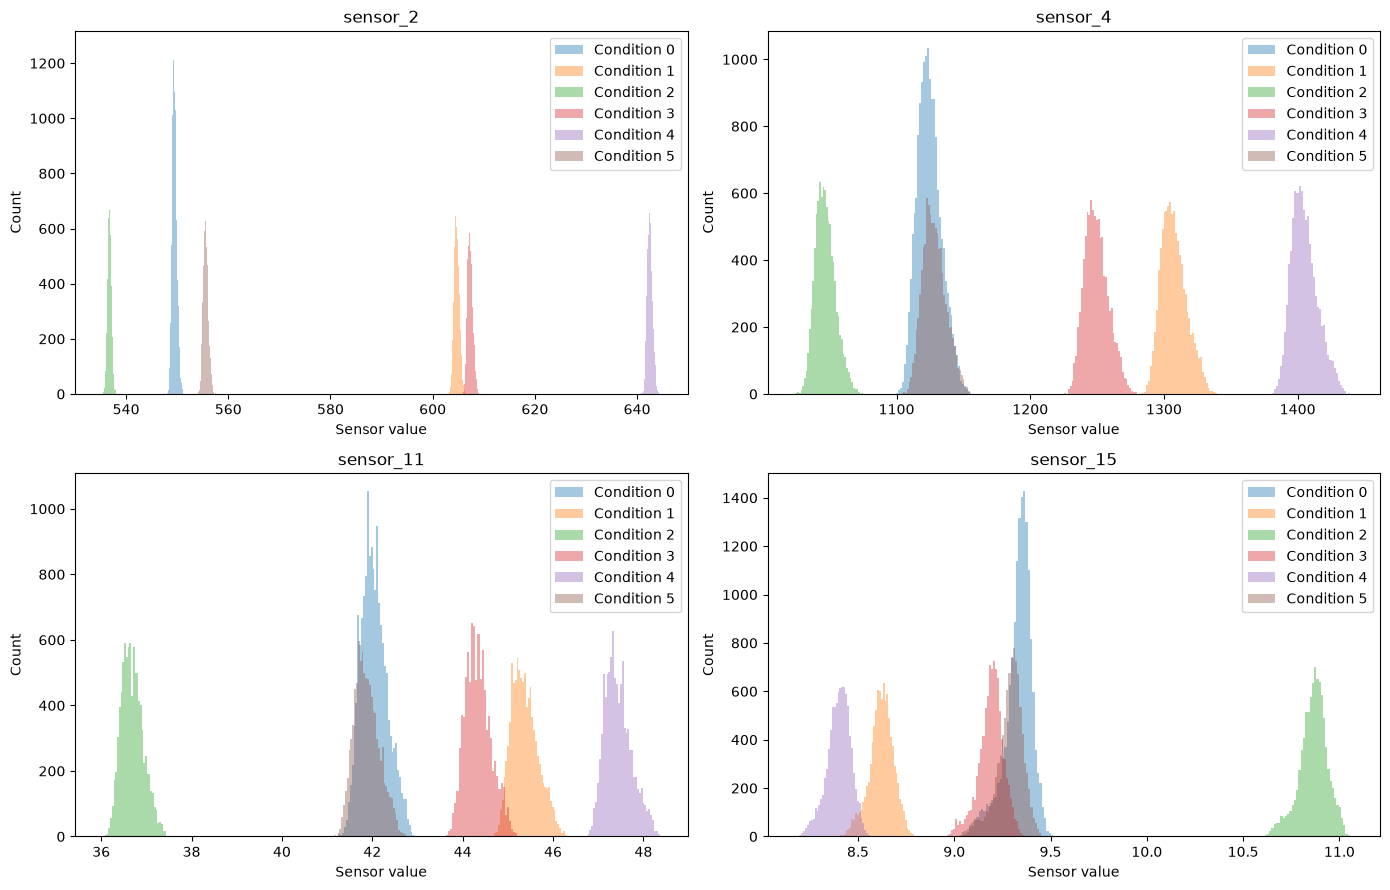

In [15]:
import matplotlib.pyplot as plt

sensors_to_plot = [
    "sensor_2",
    "sensor_4",
    "sensor_11",
    "sensor_15",
]

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(14, 9),
)

axes = axes.flatten()

for ax, sensor in zip(
    axes,
    sensors_to_plot,
):
    for condition in sorted(
        train_fd004["operating_condition"].unique()
    ):
        values = train_fd004.loc[
            train_fd004["operating_condition"] == condition,
            sensor,
        ]

        ax.hist(
            values,
            bins=40,
            alpha=0.4,
            label=f"Condition {condition}",
        )

    ax.set_title(sensor)
    ax.set_xlabel("Sensor value")
    ax.set_ylabel("Count")
    ax.legend()

plt.tight_layout()
plt.show()

In [16]:
train_fd004.operating_condition.value_counts()

operating_condition
0    15395
4     9238
1     9224
5     9162
2     9139
3     9091
Name: count, dtype: int64

In [17]:
sensor_columns = [
    col
    for col in train_fd004.columns
    if col.startswith("sensor_")
]

condition_effects = []

for sensor in sensor_columns:
    grouped = train_fd004.groupby("operating_condition")[sensor]

    # Condition 0:
    # 642.1
    # 642.3
    # 642.0
    # ...

    # Condition 1:
    # 604.9
    # 605.2
    # 604.7
    # ...

    # Condition 2:
    # ...

    condition_means = grouped.mean()
    # condition 0    642
    # condition 1    605
    # condition 2    550
    # condition 3    620
    # condition 4    590
    # condition 5    670
    
    condition_stds = grouped.std()
    # condition 0    0.5
    # condition 1    0.4
    # condition 2    0.6
    # condition 3    0.5
    # condition 4    0.4
    # condition 5    0.5

    between_condition_std = condition_means.std()
    # standard deviation of [642, 605, 550, 620, 590, 670]

    average_within_condition_std = condition_stds.mean()
    # mean of standard deviations [0.5, 0.4, 0.6, 0.5, 0.4, 0.5]

    ratio = (
        between_condition_std
        / average_within_condition_std
        if average_within_condition_std > 0
        else float("inf")
    )

    condition_effects.append({
        "sensor": sensor,
        "between_condition_std": between_condition_std,
        "avg_within_condition_std": average_within_condition_std,
        "condition_effect_ratio": ratio,
    })

condition_effect_df = pd.DataFrame(
    condition_effects
).sort_values(
    "condition_effect_ratio",
    ascending=False,
)

condition_effect_df

,sensor,between_condition_std,avg_within_condition_std,condition_effect_ratio
0,sensor_1,28.528479,0.000000,inf
18,sensor_19,6.152302,0.000000,inf
17,sensor_18,168.118312,0.000000,inf
4,sensor_5,3.861282,0.000000,inf
7,sensor_8,167.973087,0.206728,812.532453
12,sensor_13,146.890646,0.216963,677.030832
5,sensor_6,5.850986,0.014807,395.137078
1,sensor_2,41.517804,0.479253,86.630305
11,sensor_12,150.788527,1.784017,84.521899
6,sensor_7,159.903155,1.902518,84.048152


In [18]:
import numpy as np
from sklearn.model_selection import train_test_split

In [19]:
# ============================================================
# Configuration
# ============================================================

SEED = 42
RUL_CAP = 125
WINDOW = 30

setting_columns = [
    "setting_1",
    "setting_2",
    "setting_3",
]

sensor_columns = [
    f"sensor_{i}"
    for i in range(1, 22)
]


# ============================================================
# Create training RUL target
# ============================================================

train_fd004 = train_fd004.copy()

maximum_cycles = (
    train_fd004
    .groupby("engine_id")["cycle"]
    .transform("max")
)

train_fd004["rul"] = (
    maximum_cycles - train_fd004["cycle"]
)

train_fd004["rul_capped"] = (
    train_fd004["rul"].clip(upper=RUL_CAP)
)


# ============================================================
# Split by engine
# ============================================================

all_engine_ids = (
    train_fd004["engine_id"]
    .unique()
)

train_engine_ids, val_engine_ids = train_test_split(
    all_engine_ids,
    test_size=0.20,
    random_state=SEED,
)

fd004_train_split = (
    train_fd004[
        train_fd004["engine_id"].isin(train_engine_ids)
    ]
    .copy()
)

fd004_val_split = (
    train_fd004[
        train_fd004["engine_id"].isin(val_engine_ids)
    ]
    .copy()
)


# ============================================================
# Fit operating-condition model on training settings only
# ============================================================

condition_settings_scaler = StandardScaler()

train_settings_scaled = (
    condition_settings_scaler.fit_transform(
        fd004_train_split[setting_columns]
    )
)

val_settings_scaled = (
    condition_settings_scaler.transform(
        fd004_val_split[setting_columns]
    )
)

condition_kmeans = KMeans(
    n_clusters=6,
    random_state=SEED,
    n_init=20,
)

fd004_train_split["operating_condition"] = (
    condition_kmeans.fit_predict(
        train_settings_scaled
    )
)

fd004_val_split["operating_condition"] = (
    condition_kmeans.predict(
        val_settings_scaled
    )
)


# ============================================================
# Verify the split and conditions
# ============================================================

print("Training engines:", len(train_engine_ids))
print("Validation engines:", len(val_engine_ids))

print()
print("Training rows:", len(fd004_train_split))
print("Validation rows:", len(fd004_val_split))

print()
print("Training condition counts:")
print(
    fd004_train_split["operating_condition"]
    .value_counts()
    .sort_index()
)

print()
print("Validation condition counts:")
print(
    fd004_val_split["operating_condition"]
    .value_counts()
    .sort_index()
)

print()
print("Average settings for each training condition:")
print(
    fd004_train_split
    .groupby("operating_condition")[setting_columns]
    .mean()
)

Training engines: 199
Validation engines: 50

Training rows: 49294
Validation rows: 11955

Training condition counts:
operating_condition
0     7375
1     7447
2     7371
3     7307
4     7385
5    12409
Name: count, dtype: int64

Validation condition counts:
operating_condition
0    1787
1    1791
2    1768
3    1784
4    1839
5    2986
Name: count, dtype: int64

Average settings for each training condition:
                     setting_1  setting_2  setting_3
operating_condition                                 
0                    35.003022   0.840503      100.0
1                     0.001509   0.000494      100.0
2                    25.003078   0.620507       60.0
3                    20.002993   0.700502      100.0
4                    10.002997   0.250505      100.0
5                    42.002986   0.840495      100.0


##### Normalizing every sensor according to it's assigned operating conditions

In [20]:
condition_sensor_means = (
    fd004_train_split
    .groupby('operating_condition')[sensor_columns]
    .mean()
)

condition_sensor_means

,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
operating_condition,,,,,,,,,,,,,,,,,,,,,
0,449.44,555.553261,1364.632678,1128.054342,5.48,7.990441,194.925699,2223.043805,8356.038052,1.023567,...,183.461775,2388.141368,8073.881991,9.286157,0.020000,333.700746,2223.0,100.00,14.884157,8.931210
1,518.67,642.483634,1588.388505,1404.945189,14.62,21.599064,555.160177,2388.082794,9063.576667,1.301249,...,523.071474,2388.082345,8143.628143,8.399156,0.030000,392.644152,2388.0,100.00,38.983001,23.393158
2,462.54,536.731674,1260.535037,1046.561297,7.05,9.018014,175.788721,1915.414225,8014.125305,0.939710,...,164.898654,2028.312689,7878.063458,10.861907,0.020000,306.790666,1915.0,84.93,14.312688,8.589632
3,491.19,607.314192,1483.398489,1249.388232,9.35,13.638995,335.266455,2324.001994,8729.507241,1.078117,...,315.581856,2388.133488,8067.274253,9.188223,0.021594,364.799097,2324.0,100.00,24.538348,14.723898
4,489.05,604.688360,1499.865452,1307.182489,10.52,15.482074,395.445026,2318.938624,8785.869217,1.260688,...,372.484750,2388.141383,8137.030037,8.619646,0.029996,369.155450,2319.0,100.00,28.642026,17.183675
5,445.00,549.462693,1352.396842,1124.234204,3.91,5.707889,138.940999,2212.009208,8327.602383,1.022601,...,130.833826,2388.093598,8090.841773,9.329889,0.020000,330.501733,2212.0,100.00,10.624424,6.374094


In [21]:
condition_sensor_stds = (
    fd004_train_split
    .groupby("operating_condition")[sensor_columns]
    .std()
)

# Some sensorsmay by constant, or almost constant therefore we
# are defining a min std deviation 
MINIMUM_STD = 1e-6

condition_sensor_stds = (
    condition_sensor_stds
    .fillna(0.0)
    .clip(lower=MINIMUM_STD)
)

condition_sensor_stds

,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
operating_condition,,,,,,,,,,,,,,,,,,,,,
0,0.000001,0.485626,6.479077,8.676027,0.000001,0.013272,1.387985,0.256963,17.934138,0.006852,...,1.293043,0.275755,15.966335,0.069581,0.000001,1.629025,0.000001,0.000001,0.135750,0.080790
1,0.000001,0.512769,6.728066,9.752195,0.000001,0.014872,3.485798,0.148753,19.427813,0.003526,...,3.299937,0.149078,16.136643,0.060620,0.000001,1.740906,0.000001,0.000001,0.253113,0.151712
2,0.000001,0.385595,5.846499,7.407985,0.000001,0.012111,1.050053,0.209182,13.319201,0.001841,...,0.969727,0.221869,11.744534,0.072732,0.000001,1.434977,0.000001,0.000001,0.128253,0.076507
3,0.000001,0.508126,6.642222,8.870957,0.000001,0.023135,2.174939,0.209927,18.008955,0.005756,...,2.045641,0.215680,15.284162,0.065414,0.003661,1.683606,0.000001,0.000001,0.174507,0.104258
4,0.000001,0.516263,6.495301,9.326760,0.000001,0.014684,2.396712,0.182322,18.808987,0.003168,...,2.258400,0.187441,15.847182,0.061591,0.000202,1.643693,0.000001,0.000001,0.191264,0.115198
5,0.000001,0.458932,6.578160,8.993418,0.000001,0.010642,1.038347,0.234164,18.504691,0.007068,...,0.957326,0.253139,16.715050,0.071699,0.000001,1.657394,0.000001,0.000001,0.118471,0.071337


In [22]:
def apply_condition_wise_normalization(
        dataframe,
        sensor_means,
        sensor_stds,
        sensor_columns,
):
    """
    Normalize every row using statistics for that row's assigned
    operating conditions
    """

    normalized_df = dataframe.copy()

    row_conditions = normalized_df['operating_condition']

    row_means = (
        sensor_means
        .loc[row_conditions]
        .to_numpy()
    )

    row_stds = (
        sensor_stds
        .loc[row_conditions]
        .to_numpy()
    )

    normalized_df[sensor_columns] = (
        normalized_df[sensor_columns].to_numpy()
        - row_means
    )/ row_stds

    return normalized_df

In [23]:
fd004_train_normalized = apply_condition_wise_normalization(
    fd004_train_split,
    condition_sensor_means,
    condition_sensor_stds,
    sensor_columns,
)

fd004_val_normalized = apply_condition_wise_normalization(
    fd004_val_split,
    condition_sensor_means,
    condition_sensor_stds,
    sensor_columns,
)


In [24]:
# ============================================================
# Check normalized training statistics
# ============================================================

normalized_condition_means = (
    fd004_train_normalized
    .groupby("operating_condition")[sensor_columns]
    .mean()
)

print(
    "Largest absolute condition-wise mean after normalization:",
    normalized_condition_means.abs().max().max(),
)

print()

fd004_train_normalized[
    sensor_columns + ["rul_capped"]
].head(12)


Largest absolute condition-wise mean after normalization: 3.469446951953614e-12



,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,rul_capped
0,0.0,0.473506,-1.363123,-1.256942,0.0,-0.741260,-1.522612,-0.637193,-0.879906,-1.782919,...,-0.409255,-0.957926,0.050359,0.000000e+00,-0.302724,0.0,0.0,-0.037344,-0.099445,125
1,0.0,-2.448590,-0.871469,-1.340130,0.0,-1.253309,-1.455883,-1.629110,-0.883296,-1.410074,...,-1.870769,-1.383409,0.047033,-4.354902e-01,-2.256523,0.0,0.0,-0.964706,-0.658921,125
2,0.0,-1.117145,-1.410249,-0.798829,0.0,-1.680917,-0.732895,-0.380963,-1.130113,-1.782919,...,-0.488263,-1.449100,0.987615,0.000000e+00,-0.906081,0.0,0.0,-1.219072,0.661734,125
3,0.0,-1.661888,-1.696043,-0.689861,0.0,-0.741260,-0.925509,-0.551783,-0.824244,-0.368054,...,-0.290742,-0.884937,0.097780,0.000000e+00,-1.509438,0.0,0.0,-0.712618,0.609867,125
4,0.0,-1.638181,-0.907387,-1.750988,0.0,-1.487451,-0.922544,-0.928497,-1.440425,-5.274162,...,-1.048768,-1.044184,-0.347946,-3.469447e-12,-1.247871,0.0,0.0,-2.204144,1.121034,125
5,0.0,-1.612891,-1.815487,-1.272972,0.0,-1.540155,-0.796622,-1.065543,-0.894275,-0.520621,...,-0.984090,-1.238981,0.696206,0.000000e+00,-2.271755,0.0,0.0,0.190369,-0.315755,125
6,0.0,-1.274715,-0.731043,-1.133610,0.0,-1.281838,-0.777491,-1.094394,-0.673090,-0.354153,...,-1.290232,-0.973446,-0.052058,0.000000e+00,-0.944423,0.0,0.0,-0.209397,0.426083,125
7,0.0,-0.899248,-1.252150,-1.497118,0.0,-1.680917,-1.744118,-0.380963,-1.098229,-1.782919,...,-0.488263,-0.888527,0.530145,0.000000e+00,-0.906081,0.0,0.0,-0.628208,-1.337236,125
8,0.0,0.190239,-1.451294,-2.508969,0.0,-0.741260,-0.886986,-0.466373,-1.069587,-0.368054,...,-0.369751,-1.179283,0.118701,0.000000e+00,-1.509438,0.0,0.0,0.047065,-0.961553,125
9,0.0,-0.989832,-1.475248,-0.700770,0.0,-0.661724,-1.036824,-0.880691,-0.622808,0.157702,...,-0.823410,-0.736807,0.717606,-3.469447e-12,-1.247871,0.0,0.0,0.212958,0.291050,125


In [25]:
# ============================================================
# Verify condition-wise normalization
# ============================================================

train_normalized_means = (
    fd004_train_normalized
    .groupby("operating_condition")[sensor_columns]
    .mean()
)
"""
Mean of every normalized sensor within each operating condition.

Rows represent the six operating conditions.
Columns represent the 21 sensors.

Because the normalization means were calculated from the training
split, each value in this table should be extremely close to zero.
"""


train_normalized_stds = (
    fd004_train_normalized
    .groupby("operating_condition")[sensor_columns]
    .std()
)
"""
Standard deviation of every normalized sensor within each operating
condition in the training split.

For every sensor that originally had meaningful variation within its
condition, its normalized standard deviation should be close to 1.

Sensors that were constant within a condition can still have a
standard deviation of 0 after normalization. They must therefore be
excluded when checking whether standard deviations became 1.
"""


# Identify condition-sensor combinations that had enough variation
# before normalization to be standardized normally.
nonconstant_sensor_mask = (
    condition_sensor_stds > MINIMUM_STD
)
"""
Boolean DataFrame identifying non-constant condition-sensor pairs.

It has the same rows and columns as condition_sensor_stds:

    True:
        The sensor's standard deviation under that condition was
        greater than MINIMUM_STD, so its normalized standard
        deviation should be approximately 1.

    False:
        The sensor was constant or nearly constant under that
        condition. Its standard deviation was replaced with
        MINIMUM_STD to prevent division by zero, so we should not
        expect its normalized standard deviation to become 1.
"""


maximum_absolute_mean = (
    train_normalized_means
    .abs()
    .max()
    .max()
)
"""
Largest absolute normalized mean found across all sensors and all
operating conditions.

Processing:

    .abs()
        Converts negative means to positive magnitudes.

    first .max()
        Finds the largest absolute mean for each sensor across
        operating conditions.

    second .max()
        Finds the single largest value across all sensors.

A value extremely close to 0 indicates that condition-wise centering
worked correctly. Tiny values such as 1e-12 are normal floating-point
rounding errors.
"""


maximum_std_difference = (
    train_normalized_stds
    .where(nonconstant_sensor_mask)
    .sub(1.0)
    .abs()
    .max()
    .max()
)
"""
Largest difference between an observed normalized standard deviation
and the expected standard deviation of 1.

Processing:

    .where(nonconstant_sensor_mask)
        Keeps standard deviations only for non-constant sensors.
        Constant or nearly constant combinations are replaced with
        NaN so they are ignored by the later maximum operations.

    .sub(1.0)
        Subtracts the expected normalized standard deviation of 1.

    .abs()
        Measures the size of the difference regardless of direction.

    first .max()
        Finds the largest difference for each sensor.

    second .max()
        Finds the largest difference across every sensor and
        operating condition.

A value extremely close to 0 means that condition-wise scaling worked
correctly for all sensors that had meaningful variation.
"""


# Check whether normalization created invalid numerical values.
train_values_are_finite = np.isfinite(
    fd004_train_normalized[sensor_columns].to_numpy()
).all()
"""
True when every normalized training sensor value is a valid finite
number.

np.isfinite() returns False for:

    NaN
    positive infinity
    negative infinity

.to_numpy() converts the selected sensor DataFrame into a NumPy array.
.all() returns True only if every value in that array is finite.
"""


val_values_are_finite = np.isfinite(
    fd004_val_normalized[sensor_columns].to_numpy()
).all()
"""
True when every normalized validation sensor value is a valid finite
number.

This check is important because validation rows use condition
statistics learned from the training split. A missing condition,
missing statistic, or unsafe division could otherwise introduce NaN
or infinity.
"""


print(
    "Maximum absolute training mean:",
    maximum_absolute_mean,
)

print(
    "Maximum difference from standard deviation 1:",
    maximum_std_difference,
)

print(
    "All training sensor values finite:",
    train_values_are_finite,
)

print(
    "All validation sensor values finite:",
    val_values_are_finite,
)

Maximum absolute training mean: 3.469446951953614e-12
Maximum difference from standard deviation 1: 1.4359624600501775e-12
All training sensor values finite: True
All validation sensor values finite: True


In [26]:
(train_normalized_stds
    .where(nonconstant_sensor_mask)
    .sub(1.0)
    .abs()
    .max())

sensor_1              NaN
sensor_2     7.727152e-14
sensor_3     1.554312e-14
sensor_4     1.332268e-14
sensor_5              NaN
sensor_6     2.529088e-13
sensor_7     1.942890e-14
sensor_8     8.273382e-13
sensor_9     2.331468e-14
sensor_10    1.532108e-14
sensor_11    2.331468e-14
sensor_12    8.548717e-15
sensor_13    1.435962e-12
sensor_14    2.731149e-14
sensor_15    3.330669e-14
sensor_16    1.998401e-15
sensor_17    2.275957e-14
sensor_18             NaN
sensor_19             NaN
sensor_20    1.221245e-14
sensor_21    2.287059e-14
dtype: float64

In [27]:
train_normalized_stds

,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
operating_condition,,,,,,,,,,,,,,,,,,,,,
0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0
1,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0
2,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0
3,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0
4,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0
5,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0


In [28]:
(train_normalized_stds
    .where(nonconstant_sensor_mask))

,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
operating_condition,,,,,,,,,,,,,,,,,,,,,
0,NaN,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,NaN,1.0,NaN,NaN,1.0,1.0
1,NaN,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,NaN,1.0,NaN,NaN,1.0,1.0
2,NaN,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,NaN,1.0,NaN,NaN,1.0,1.0
3,NaN,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,1.0,1.0
4,NaN,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,1.0,1.0
5,NaN,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,NaN,1.0,NaN,NaN,1.0,1.0


##### As we have seen there are 6 different operating conditions which are very different

Therefore we will add one hot features for the operating conditions

In [29]:
# ============================================================
# Add one-hot operating-condition features
# ============================================================

condition_columns = [
    f"condition_{condition}"
    for condition in range(6)
]
"""One binary feature column for each operating condition."""


for condition, column in enumerate(condition_columns):
    fd004_train_normalized[column] = (
        fd004_train_normalized["operating_condition"]
        == condition
    ).astype(np.float32)

    fd004_val_normalized[column] = (
        fd004_val_normalized["operating_condition"]
        == condition
    ).astype(np.float32)


sequence_feature_columns = (
    sensor_columns + condition_columns
)
"""Features provided to the LSTM at every timestep."""


print("Number of sequence features:", len(sequence_feature_columns))
print("Sequence features:", sequence_feature_columns)

print()
(
    fd004_train_normalized[
        ["operating_condition"] + condition_columns
    ].head()
)

Number of sequence features: 27
Sequence features: ['sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21', 'condition_0', 'condition_1', 'condition_2', 'condition_3', 'condition_4', 'condition_5']



,operating_condition,condition_0,condition_1,condition_2,condition_3,condition_4,condition_5
0,5,0.0,0.0,0.0,0.0,0.0,1.0
1,3,0.0,0.0,0.0,1.0,0.0,0.0
2,5,0.0,0.0,0.0,0.0,0.0,1.0
3,5,0.0,0.0,0.0,0.0,0.0,1.0
4,2,0.0,0.0,1.0,0.0,0.0,0.0


In [30]:
fd004_train_normalized.head()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_21,operating_condition,rul,rul_capped,condition_0,condition_1,condition_2,condition_3,condition_4,condition_5
0,1,1,42.0049,0.8400,100.0,0.0,0.473506,-1.363123,-1.256942,0.0,...,-0.099445,5,320,125,0.0,0.0,0.0,0.0,0.0,1.0
1,1,2,20.0020,0.7002,100.0,0.0,-2.448590,-0.871469,-1.340130,0.0,...,-0.658921,3,319,125,0.0,0.0,0.0,1.0,0.0,0.0
2,1,3,42.0038,0.8409,100.0,0.0,-1.117145,-1.410249,-0.798829,0.0,...,0.661734,5,318,125,0.0,0.0,0.0,0.0,0.0,1.0
3,1,4,42.0000,0.8400,100.0,0.0,-1.661888,-1.696043,-0.689861,0.0,...,0.609867,5,317,125,0.0,0.0,0.0,0.0,0.0,1.0
4,1,5,25.0063,0.6207,60.0,0.0,-1.638181,-0.907387,-1.750988,0.0,...,1.121034,2,316,125,0.0,0.0,1.0,0.0,0.0,0.0


In [36]:
# ============================================================
# Imports
# ============================================================

import copy
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from sklearn.metrics import mean_absolute_error, mean_squared_error
from torch.utils.data import DataLoader, TensorDataset


# ============================================================
# 1. Select computation device
# ============================================================

DEVICE = torch.device(
    "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
"""Device used for model training and inference."""

print("Using device:", DEVICE)

def create_sequences(
    dataframe,
    feature_columns,
    target_column="rul_capped",
    window=30,
):
    """
    Create chronological sliding-window sequences separately
    for every engine.

    The target is the RUL at the sequence's final timestep.
    """
    sequences = []
    targets = []

    sorted_dataframe = dataframe.sort_values(
        ["engine_id", "cycle"]
    )

    for _, engine_data in sorted_dataframe.groupby(
        "engine_id",
        sort=False,
    ):
        engine_features = engine_data[
            feature_columns
        ].to_numpy(dtype=np.float32)

        engine_targets = engine_data[
            target_column
        ].to_numpy(dtype=np.float32)

        for end_index in range(
            window - 1,
            len(engine_data),
        ):
            start_index = end_index - window + 1

            sequences.append(
                engine_features[
                    start_index:end_index + 1
                ]
            )

            targets.append(
                engine_targets[end_index]
            )

    if not sequences:
        raise ValueError(
            "No sequences were created. Check the window size "
            "and the number of rows available per engine."
        )

    X = np.stack(sequences).astype(
        np.float32
    )

    y = np.asarray(
        targets,
        dtype=np.float32,
    )

    return X, y


# ============================================================
# 2. Reproducibility
# ============================================================

def set_random_seed(seed):
    """
    Set Python, NumPy, and PyTorch random seeds.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)


# ============================================================
# 3. LSTM model
# ============================================================

class RULPredictor(nn.Module):
    """
    Predict one RUL value from each multivariate sequence.
    """

    def __init__(
        self,
        input_size,
        hidden_size=64,
        num_layers=1,
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )

        self.output_layer = nn.Linear(
            hidden_size,
            1,
        )

    def forward(self, sequences):
        """
        Use the final LSTM timestep to predict RUL.
        """
        lstm_output, _ = self.lstm(sequences)

        final_hidden = lstm_output[:, -1, :]

        predictions = self.output_layer(
            final_hidden
        )

        return predictions.squeeze(1)


# ============================================================
# 4. Asymmetric loss
# ============================================================

def asymmetric_mse(
    predictions,
    targets,
    overprediction_weight=2.0,
):
    """
    Penalize unsafe RUL overprediction more heavily.
    """
    errors = predictions - targets

    weights = torch.where(
        errors > 0,
        torch.full_like(
            errors,
            overprediction_weight,
        ),
        torch.ones_like(errors),
    )

    return torch.mean(
        weights * errors.pow(2)
    )


# ============================================================
# 5. Create DataLoaders
# ============================================================

def create_loaders(
    X_train,
    y_train,
    X_val,
    y_val,
    batch_size=64,
    seed=42,
):
    """
    Convert NumPy arrays into training and validation loaders.
    """
    X_train_tensor = torch.tensor(
        X_train,
        dtype=torch.float32,
    )

    y_train_tensor = torch.tensor(
        y_train,
        dtype=torch.float32,
    )

    X_val_tensor = torch.tensor(
        X_val,
        dtype=torch.float32,
    )

    y_val_tensor = torch.tensor(
        y_val,
        dtype=torch.float32,
    )

    train_dataset = TensorDataset(
        X_train_tensor,
        y_train_tensor,
    )

    val_dataset = TensorDataset(
        X_val_tensor,
        y_val_tensor,
    )

    shuffle_generator = (
        torch.Generator().manual_seed(seed)
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        generator=shuffle_generator,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
    )

    return (
        train_loader,
        val_loader,
        X_val_tensor,
        y_val_tensor,
    )


# ============================================================
# 6. Train on MPS with early stopping
# ============================================================

def train_model(
    model,
    train_loader,
    val_loader,
    device,
    epochs=30,
    learning_rate=0.001,
    overprediction_weight=2.0,
    patience=5,
    minimum_improvement=0.0,
):
    """
    Train on the selected device and stop after validation
    loss fails to improve for the requested patience.
    """
    model = model.to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
    )

    history = {
        "train_loss": [],
        "val_loss": [],
    }

    best_val_loss = float("inf")
    best_model_state = None
    best_epoch = 0
    epochs_without_improvement = 0

    for epoch in range(1, epochs + 1):

        # -------------------------
        # Training
        # -------------------------

        model.train()

        total_train_loss = 0.0

        for batch_sequences, batch_targets in train_loader:
            batch_sequences = batch_sequences.to(device)
            batch_targets = batch_targets.to(device)

            optimizer.zero_grad()

            batch_predictions = model(
                batch_sequences
            )

            loss = asymmetric_mse(
                batch_predictions,
                batch_targets,
                overprediction_weight,
            )

            loss.backward()
            optimizer.step()

            total_train_loss += (
                loss.item()
                * len(batch_sequences)
            )

        average_train_loss = (
            total_train_loss
            / len(train_loader.dataset)
        )

        # -------------------------
        # Validation
        # -------------------------

        model.eval()

        total_val_loss = 0.0

        with torch.no_grad():
            for batch_sequences, batch_targets in val_loader:
                batch_sequences = batch_sequences.to(device)
                batch_targets = batch_targets.to(device)

                batch_predictions = model(
                    batch_sequences
                )

                loss = asymmetric_mse(
                    batch_predictions,
                    batch_targets,
                    overprediction_weight,
                )

                total_val_loss += (
                    loss.item()
                    * len(batch_sequences)
                )

        average_val_loss = (
            total_val_loss
            / len(val_loader.dataset)
        )

        history["train_loss"].append(
            average_train_loss
        )

        history["val_loss"].append(
            average_val_loss
        )

        print(
            f"Epoch {epoch:02d} | "
            f"Train Loss: {average_train_loss:.2f} | "
            f"Val Loss: {average_val_loss:.2f}"
        )

        # -------------------------
        # Best checkpoint
        # -------------------------

        improved = (
            average_val_loss
            < best_val_loss - minimum_improvement
        )

        if improved:
            best_val_loss = average_val_loss
            best_epoch = epoch

            best_model_state = copy.deepcopy(
                model.state_dict()
            )

            epochs_without_improvement = 0

        else:
            epochs_without_improvement += 1

        # -------------------------
        # Early stopping
        # -------------------------

        if epochs_without_improvement >= patience:
            print()
            print(
                "Early stopping: validation loss did not "
                f"improve for {patience} epochs."
            )
            break

    if best_model_state is None:
        raise RuntimeError(
            "Training did not produce a valid checkpoint."
        )

    model.load_state_dict(best_model_state)

    print(
        f"Restored checkpoint from epoch {best_epoch}."
    )

    return (
        model,
        history,
        best_epoch,
        best_val_loss,
    )


# ============================================================
# 7. Evaluate on MPS
# ============================================================

def evaluate_model(
    model,
    X_tensor,
    y_true,
    device,
    batch_size=256,
):
    """
    Predict in batches on the selected device and calculate
    MAE, MSE, and RMSE on the CPU.
    """
    model = model.to(device)
    model.eval()

    evaluation_dataset = TensorDataset(
        X_tensor
    )

    evaluation_loader = DataLoader(
        evaluation_dataset,
        batch_size=batch_size,
        shuffle=False,
    )

    prediction_batches = []

    with torch.no_grad():
        for (batch_sequences,) in evaluation_loader:
            batch_sequences = batch_sequences.to(device)

            batch_predictions = model(
                batch_sequences
            )

            prediction_batches.append(
                batch_predictions.cpu().numpy()
            )

    predictions = np.concatenate(
        prediction_batches
    )

    if isinstance(y_true, torch.Tensor):
        actual_values = y_true.cpu().numpy()
    else:
        actual_values = np.asarray(y_true)

    mae = mean_absolute_error(
        actual_values,
        predictions,
    )

    mse = mean_squared_error(
        actual_values,
        predictions,
    )

    rmse = np.sqrt(mse)

    return {
        "predictions": predictions,
        "mae": mae,
        "mse": mse,
        "rmse": rmse,
    }


# ============================================================
# 8. Plot training history
# ============================================================

def plot_training_history(history):
    """
    Plot training and validation loss for completed epochs.
    """
    completed_epochs = range(
        1,
        len(history["train_loss"]) + 1,
    )

    plt.figure(figsize=(10, 5))

    plt.plot(
        completed_epochs,
        history["train_loss"],
        label="Training loss",
    )

    plt.plot(
        completed_epochs,
        history["val_loss"],
        label="Validation loss",
    )

    plt.xlabel("Epoch")
    plt.ylabel("Asymmetric MSE")
    plt.title("FD004 LSTM training history")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


# ============================================================
# 9. Create metadata aligned with sequences
# ============================================================

def create_sequence_metadata(
    dataframe,
    window,
):
    """
    Record the engine, ending cycle, and final condition of
    every sliding-window sequence.
    """
    metadata = []

    sorted_dataframe = dataframe.sort_values(
        ["engine_id", "cycle"]
    )

    for engine_id, engine_data in sorted_dataframe.groupby(
        "engine_id",
        sort=False,
    ):
        for end_index in range(
            window - 1,
            len(engine_data),
        ):
            ending_row = engine_data.iloc[end_index]

            metadata.append({
                "engine_id": int(engine_id),
                "ending_cycle": int(
                    ending_row["cycle"]
                ),
                "ending_condition": int(
                    ending_row["operating_condition"]
                ),
            })

    return pd.DataFrame(metadata)


# ============================================================
# 10. Calculate metrics by ending condition
# ============================================================

def calculate_condition_metrics(
    actual_values,
    predictions,
    sequence_metadata,
):
    """
    Calculate validation metrics for each final operating
    condition.
    """
    metric_rows = []

    condition_values = (
        sequence_metadata["ending_condition"]
        .to_numpy()
    )

    for condition in sorted(
        np.unique(condition_values)
    ):
        condition_mask = (
            condition_values == condition
        )

        condition_actual = actual_values[
            condition_mask
        ]

        condition_predictions = predictions[
            condition_mask
        ]

        condition_errors = (
            condition_predictions
            - condition_actual
        )

        condition_mse = mean_squared_error(
            condition_actual,
            condition_predictions,
        )

        metric_rows.append({
            "condition": condition,
            "sequence_count": condition_mask.sum(),
            "mae": mean_absolute_error(
                condition_actual,
                condition_predictions,
            ),
            "rmse": np.sqrt(condition_mse),
            "mean_error": condition_errors.mean(),
        })

    return (
        pd.DataFrame(metric_rows)
        .sort_values("condition")
        .reset_index(drop=True)
    )


# ============================================================
# 11. Plot errors colored by ending condition
# ============================================================

def plot_errors_by_condition(
    actual_values,
    predictions,
    sequence_metadata,
):
    """
    Color each prediction error by the operating condition at
    the sequence's final timestep.
    """
    errors = predictions - actual_values

    condition_values = (
        sequence_metadata["ending_condition"]
        .to_numpy()
    )

    color_map = plt.get_cmap("tab10")

    plt.figure(figsize=(12, 7))

    for condition in sorted(
        np.unique(condition_values)
    ):
        condition_mask = (
            condition_values == condition
        )

        plt.scatter(
            actual_values[condition_mask],
            errors[condition_mask],
            alpha=0.30,
            s=14,
            color=color_map(condition),
            label=f"Condition {condition}",
        )

    plt.axhline(
        y=0,
        color="black",
        linestyle="--",
    )

    plt.xlabel("Actual capped RUL")
    plt.ylabel("Prediction error")
    plt.title(
        "FD004 validation errors by ending condition"
    )

    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

Using device: mps


Training sequences: (43523, 30, 27)
Training targets: (43523,)

Validation sequences: (10505, 30, 27)
Validation targets: (10505,)
Epoch 01 | Train Loss: 5870.41 | Val Loss: 3437.36
Epoch 02 | Train Loss: 2270.32 | Val Loss: 1394.88
Epoch 03 | Train Loss: 936.23 | Val Loss: 720.58
Epoch 04 | Train Loss: 489.29 | Val Loss: 535.20
Epoch 05 | Train Loss: 335.70 | Val Loss: 481.96
Epoch 06 | Train Loss: 283.16 | Val Loss: 477.61
Epoch 07 | Train Loss: 255.23 | Val Loss: 445.05
Epoch 08 | Train Loss: 232.14 | Val Loss: 403.23
Epoch 09 | Train Loss: 223.17 | Val Loss: 424.10
Epoch 10 | Train Loss: 212.89 | Val Loss: 429.24
Epoch 11 | Train Loss: 206.41 | Val Loss: 421.01
Epoch 12 | Train Loss: 197.90 | Val Loss: 421.43
Epoch 13 | Train Loss: 192.73 | Val Loss: 420.89

Early stopping: validation loss did not improve for 5 epochs.
Restored checkpoint from epoch 8.

FD004 condition-aware LSTM using: mps
Best epoch: 8
Best asymmetric validation loss: 403.23
Validation MAE: 12.76
Validation MSE: 

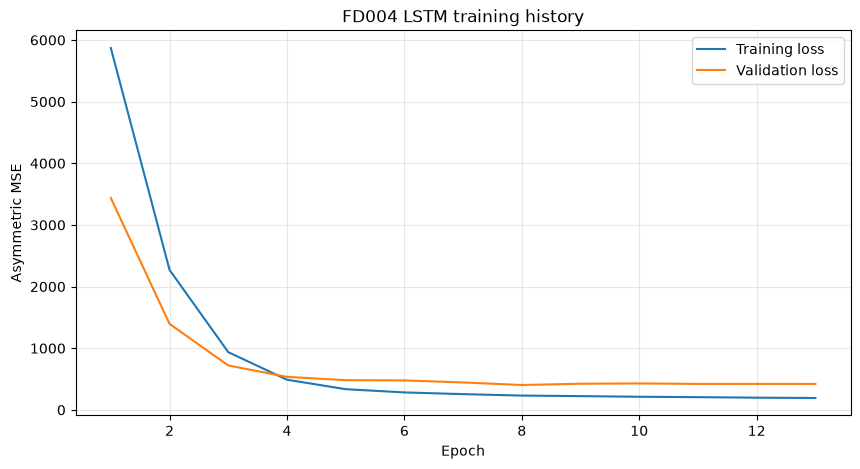


Validation metrics by ending condition:


,condition,sequence_count,mae,rmse,mean_error
0,0,1577,13.006835,17.950627,-5.457429
1,1,1588,12.782068,17.791769,-5.612226
2,2,1569,13.073799,18.123165,-5.393585
3,3,1576,12.797748,17.648358,-5.263023
4,4,1609,12.539865,17.744284,-4.579690
5,5,2586,12.513009,17.342560,-5.108088


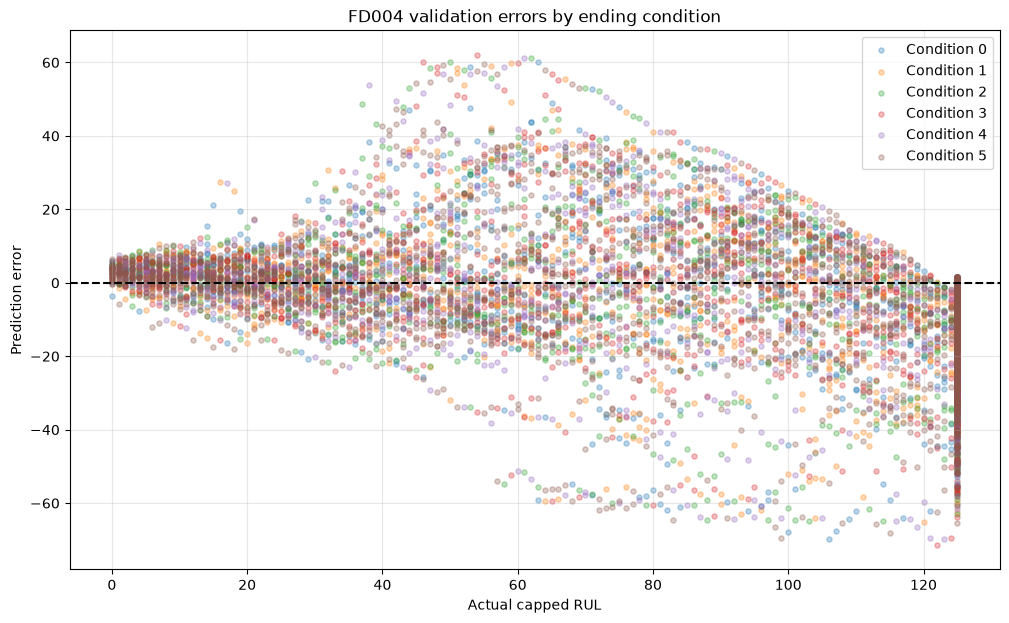

In [37]:
# ============================================================
# FD004 MPS training configuration
# ============================================================

HIDDEN_SIZE = 64
"""Number of LSTM hidden features."""

NUM_LAYERS = 1
"""Number of stacked LSTM layers."""

BATCH_SIZE = 64
"""Number of sequences in each training batch."""

MAXIMUM_EPOCHS = 30
"""Maximum number of training epochs."""

LEARNING_RATE = 0.001
"""Adam optimizer learning rate."""

OVERPREDICTION_WEIGHT = 2.0
"""Penalty multiplier for unsafe RUL overprediction."""

EARLY_STOPPING_PATIENCE = 5
"""Epochs allowed without validation improvement."""


set_random_seed(SEED)

# ============================================================
# Recreate FD004 sequence arrays
# ============================================================

X_train_fd004, y_train_fd004 = create_sequences(
    fd004_train_normalized,
    feature_columns=sequence_feature_columns,
    target_column="rul_capped",
    window=WINDOW,
)
"""FD004 training sequences and targets."""


X_val_fd004, y_val_fd004 = create_sequences(
    fd004_val_normalized,
    feature_columns=sequence_feature_columns,
    target_column="rul_capped",
    window=WINDOW,
)
"""FD004 validation sequences and targets."""


print("Training sequences:", X_train_fd004.shape)
print("Training targets:", y_train_fd004.shape)

print()
print("Validation sequences:", X_val_fd004.shape)
print("Validation targets:", y_val_fd004.shape)





# ============================================================
# Recreate loaders for a fresh reproducible run
# ============================================================

(
    train_loader_fd004,
    val_loader_fd004,
    X_val_fd004_tensor,
    y_val_fd004_tensor,
) = create_loaders(
    X_train_fd004,
    y_train_fd004,
    X_val_fd004,
    y_val_fd004,
    batch_size=BATCH_SIZE,
    seed=SEED,
)
"""FD004 loaders and validation tensors."""


# ============================================================
# Create a fresh model
# ============================================================

model_fd004_mps = RULPredictor(
    input_size=X_train_fd004.shape[2],
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
)
"""Fresh FD004 model that will be moved to MPS."""


# ============================================================
# Train on MPS
# ============================================================

(
    model_fd004_mps,
    history_fd004_mps,
    best_epoch_fd004_mps,
    best_val_loss_fd004_mps,
) = train_model(
    model_fd004_mps,
    train_loader_fd004,
    val_loader_fd004,
    device=DEVICE,
    epochs=MAXIMUM_EPOCHS,
    learning_rate=LEARNING_RATE,
    overprediction_weight=OVERPREDICTION_WEIGHT,
    patience=EARLY_STOPPING_PATIENCE,
)
"""MPS-trained model and its best validation checkpoint."""


# ============================================================
# Evaluate the best checkpoint
# ============================================================

results_fd004_mps = evaluate_model(
    model_fd004_mps,
    X_val_fd004_tensor,
    y_val_fd004,
    device=DEVICE,
)
"""Validation predictions and metrics from the best model."""


print()
print("FD004 condition-aware LSTM using:", DEVICE)
print("Best epoch:", best_epoch_fd004_mps)

print(
    "Best asymmetric validation loss:",
    f"{best_val_loss_fd004_mps:.2f}",
)

print(
    "Validation MAE:",
    f"{results_fd004_mps['mae']:.2f}",
)

print(
    "Validation MSE:",
    f"{results_fd004_mps['mse']:.2f}",
)

print(
    "Validation RMSE:",
    f"{results_fd004_mps['rmse']:.2f}",
)


# ============================================================
# Training history
# ============================================================

plot_training_history(
    history_fd004_mps
)


# ============================================================
# Align validation sequences with ending conditions
# ============================================================

val_sequence_metadata = create_sequence_metadata(
    fd004_val_normalized,
    window=WINDOW,
)
"""Metadata aligned with validation sequence order."""


assert (
    len(val_sequence_metadata)
    == len(y_val_fd004)
    == len(results_fd004_mps["predictions"])
)


# ============================================================
# Metrics for each ending condition
# ============================================================

condition_metrics_fd004 = calculate_condition_metrics(
    y_val_fd004,
    results_fd004_mps["predictions"],
    val_sequence_metadata,
)
"""Validation performance grouped by ending condition."""


print()
print("Validation metrics by ending condition:")
display(condition_metrics_fd004)


# ============================================================
# Colored prediction-error plot
# ============================================================

plot_errors_by_condition(
    y_val_fd004,
    results_fd004_mps["predictions"],
    val_sequence_metadata,
)

##### We will shuffle the training data to not create any problem related to "pendulum like" updates
Without shuffling one batch might contain almost identical windows that too from same engine

In [38]:
mps_is_available = torch.backends.mps.is_available()
"""Whether PyTorch can use the Mac's Apple Silicon GPU."""

print("MPS available:", mps_is_available)

MPS available: True


In [39]:
# We need to take care of overpredictions in low RUL range
def calculate_safety_metrics(
    actual_values,
    predictions,
    critical_rul=30,
    severe_error_threshold=10,
):
    """
    Measure unsafe overprediction in the critical low-RUL region.
    """
    actual_values = np.asarray(actual_values)
    predictions = np.asarray(predictions)

    critical_mask = actual_values <= critical_rul

    critical_actual = actual_values[critical_mask]
    critical_predictions = predictions[critical_mask]

    errors = critical_predictions - critical_actual
    overprediction_mask = errors > 0

    overprediction_errors = errors[overprediction_mask]

    return {
        "critical_rul_threshold": critical_rul,
        "sequence_count": len(critical_actual),
        "mae": mean_absolute_error(
            critical_actual,
            critical_predictions,
        ),
        "rmse": np.sqrt(
            mean_squared_error(
                critical_actual,
                critical_predictions,
            )
        ),
        "mean_error": errors.mean(),
        "overprediction_rate": overprediction_mask.mean(),
        "mean_overprediction": (
            overprediction_errors.mean()
            if len(overprediction_errors) > 0
            else 0.0
        ),
        "maximum_overprediction": (
            overprediction_errors.max()
            if len(overprediction_errors) > 0
            else 0.0
        ),
        "severe_overprediction_rate": (
            errors > severe_error_threshold
        ).mean(),
    }

In [40]:
safety_metrics_fd004 = calculate_safety_metrics(
    y_val_fd004,
    results_fd004_mps["predictions"],
    critical_rul=30,
    severe_error_threshold=10,
)

safety_metrics_fd004

{'critical_rul_threshold': 30,
 'sequence_count': 1550,
 'mae': 4.530731678009033,
 'rmse': np.float64(5.888406269922126),
 'mean_error': np.float32(1.4170774),
 'overprediction_rate': np.float64(0.6593548387096774),
 'mean_overprediction': np.float32(4.5103245),
 'maximum_overprediction': np.float32(27.328629),
 'severe_overprediction_rate': np.float64(0.04387096774193548)}

In [46]:
critical_error_analysis = val_sequence_metadata.copy()

critical_error_analysis["actual_rul"] = y_val_fd004
critical_error_analysis["predicted_rul"] = (
    results_fd004_mps["predictions"]
)

critical_error_analysis["error"] = (
    critical_error_analysis["predicted_rul"]
    - critical_error_analysis["actual_rul"]
)

worst_critical_predictions = (
    critical_error_analysis[
        critical_error_analysis["actual_rul"] <= 30
    ]
    .sort_values(
        "error",
        ascending=False,
    )
    .head(20)
)

display(worst_critical_predictions)

,engine_id,ending_cycle,ending_condition,actual_rul,predicted_rul,error
4391,105,154,1,16.0,43.328629,27.328629
4390,105,153,4,17.0,44.266594,27.266594
1553,25,120,2,30.0,57.244537,27.244537
4389,105,152,1,18.0,42.882965,24.882965
1554,25,121,0,29.0,51.437824,22.437824
4392,105,155,0,15.0,36.133629,21.133629
4388,105,151,0,19.0,38.519451,19.519451
1038,17,124,3,27.0,45.230103,18.230103
4386,105,149,5,21.0,38.431484,17.431484
7485,176,159,4,21.0,38.061390,17.061390


In [47]:
# ============================================================
# Safety-aware loss experiment
#
# These are NEW functions.
# Do not replace asymmetric_mse() or train_model().
# ============================================================

def safety_aware_asymmetric_mse(
    predictions,
    targets,
    overprediction_weight=2.0,
    critical_rul=30.0,
    critical_overprediction_weight=5.0,
):
    """
    Penalize RUL overprediction everywhere, with an even stronger
    penalty when the actual RUL is in the critical low-RUL region.

    Weighting:
        Underprediction:
            weight = 1

        Overprediction when actual RUL > critical_rul:
            weight = overprediction_weight

        Overprediction when actual RUL <= critical_rul:
            weight = critical_overprediction_weight
    """
    errors = predictions - targets
    """Positive error means RUL overprediction."""

    is_overprediction = errors > 0
    """True wherever predicted RUL is greater than actual RUL."""

    is_critical = targets <= critical_rul
    """True wherever actual RUL is inside the critical region."""

    weights = torch.ones_like(errors)
    """Begin with weight 1 for every prediction."""

    # Apply the normal overprediction penalty everywhere.
    weights = torch.where(
        is_overprediction,
        torch.full_like(
            errors,
            overprediction_weight,
        ),
        weights,
    )

    # Replace the normal penalty with a stronger penalty
    # when overprediction occurs close to failure.
    weights = torch.where(
        is_overprediction & is_critical,
        torch.full_like(
            errors,
            critical_overprediction_weight,
        ),
        weights,
    )

    weighted_squared_errors = (
        weights * errors.pow(2)
    )

    return weighted_squared_errors.mean()


def train_safety_model(
    model,
    train_loader,
    val_loader,
    device,
    epochs=30,
    learning_rate=0.001,
    overprediction_weight=2.0,
    critical_rul=30.0,
    critical_overprediction_weight=5.0,
    patience=5,
    minimum_improvement=0.0,
):
    """
    Train a model using safety_aware_asymmetric_mse().

    This is separate from the original train_model() function.
    It keeps the best validation checkpoint and performs early
    stopping.
    """
    model = model.to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
    )

    history = {
        "train_loss": [],
        "val_loss": [],
    }

    best_val_loss = float("inf")
    best_model_state = None
    best_epoch = 0
    epochs_without_improvement = 0

    for epoch in range(1, epochs + 1):

        # ========================================================
        # Training
        # ========================================================

        model.train()

        total_train_loss = 0.0

        for batch_sequences, batch_targets in train_loader:
            batch_sequences = batch_sequences.to(device)
            batch_targets = batch_targets.to(device)

            optimizer.zero_grad()

            batch_predictions = model(
                batch_sequences
            )

            loss = safety_aware_asymmetric_mse(
                batch_predictions,
                batch_targets,
                overprediction_weight=overprediction_weight,
                critical_rul=critical_rul,
                critical_overprediction_weight=(
                    critical_overprediction_weight
                ),
            )

            loss.backward()
            optimizer.step()

            total_train_loss += (
                loss.item()
                * len(batch_sequences)
            )

        average_train_loss = (
            total_train_loss
            / len(train_loader.dataset)
        )

        # ========================================================
        # Validation
        # ========================================================

        model.eval()

        total_val_loss = 0.0

        with torch.no_grad():
            for batch_sequences, batch_targets in val_loader:
                batch_sequences = batch_sequences.to(device)
                batch_targets = batch_targets.to(device)

                batch_predictions = model(
                    batch_sequences
                )

                loss = safety_aware_asymmetric_mse(
                    batch_predictions,
                    batch_targets,
                    overprediction_weight=overprediction_weight,
                    critical_rul=critical_rul,
                    critical_overprediction_weight=(
                        critical_overprediction_weight
                    ),
                )

                total_val_loss += (
                    loss.item()
                    * len(batch_sequences)
                )

        average_val_loss = (
            total_val_loss
            / len(val_loader.dataset)
        )

        history["train_loss"].append(
            average_train_loss
        )

        history["val_loss"].append(
            average_val_loss
        )

        print(
            f"Epoch {epoch:02d} | "
            f"Train safety loss: {average_train_loss:.2f} | "
            f"Val safety loss: {average_val_loss:.2f}"
        )

        # ========================================================
        # Save best validation checkpoint
        # ========================================================

        improved = (
            average_val_loss
            < best_val_loss - minimum_improvement
        )

        if improved:
            best_val_loss = average_val_loss
            best_epoch = epoch

            best_model_state = copy.deepcopy(
                model.state_dict()
            )

            epochs_without_improvement = 0

        else:
            epochs_without_improvement += 1

        # ========================================================
        # Early stopping
        # ========================================================

        if epochs_without_improvement >= patience:
            print()
            print(
                "Early stopping: validation safety loss "
                f"did not improve for {patience} epochs."
            )
            break

    if best_model_state is None:
        raise RuntimeError(
            "Safety-aware training did not produce "
            "a valid checkpoint."
        )

    model.load_state_dict(
        best_model_state
    )

    print()
    print(
        "Restored safety-aware checkpoint "
        f"from epoch {best_epoch}."
    )

    return (
        model,
        history,
        best_epoch,
        best_val_loss,
    )

Epoch 01 | Train safety loss: 5877.97 | Val safety loss: 3456.02
Epoch 02 | Train safety loss: 2266.18 | Val safety loss: 1401.20
Epoch 03 | Train safety loss: 922.96 | Val safety loss: 724.60
Epoch 04 | Train safety loss: 468.26 | Val safety loss: 496.89
Epoch 05 | Train safety loss: 319.31 | Val safety loss: 452.57
Epoch 06 | Train safety loss: 266.24 | Val safety loss: 448.40
Epoch 07 | Train safety loss: 239.83 | Val safety loss: 426.16
Epoch 08 | Train safety loss: 222.32 | Val safety loss: 422.24
Epoch 09 | Train safety loss: 215.41 | Val safety loss: 429.58
Epoch 10 | Train safety loss: 203.82 | Val safety loss: 438.57
Epoch 11 | Train safety loss: 196.03 | Val safety loss: 452.62
Epoch 12 | Train safety loss: 186.17 | Val safety loss: 448.78
Epoch 13 | Train safety loss: 177.71 | Val safety loss: 463.26

Early stopping: validation safety loss did not improve for 5 epochs.

Restored safety-aware checkpoint from epoch 8.

FD004 safety-aware LSTM using: mps
Best epoch: 8
Best safe

,condition,sequence_count,mae,rmse,mean_error
0,0,1577,13.040243,18.708532,-6.930909
1,1,1588,12.620129,18.559416,-6.441788
2,2,1569,12.902291,18.642779,-6.535282
3,3,1576,12.740341,18.523381,-6.607163
4,4,1609,12.636265,18.562888,-5.982590
5,5,2586,12.624375,18.163959,-6.316856


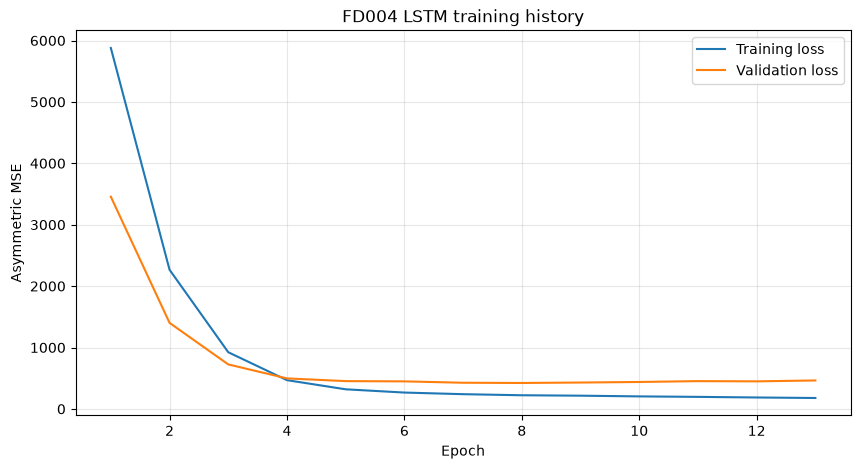

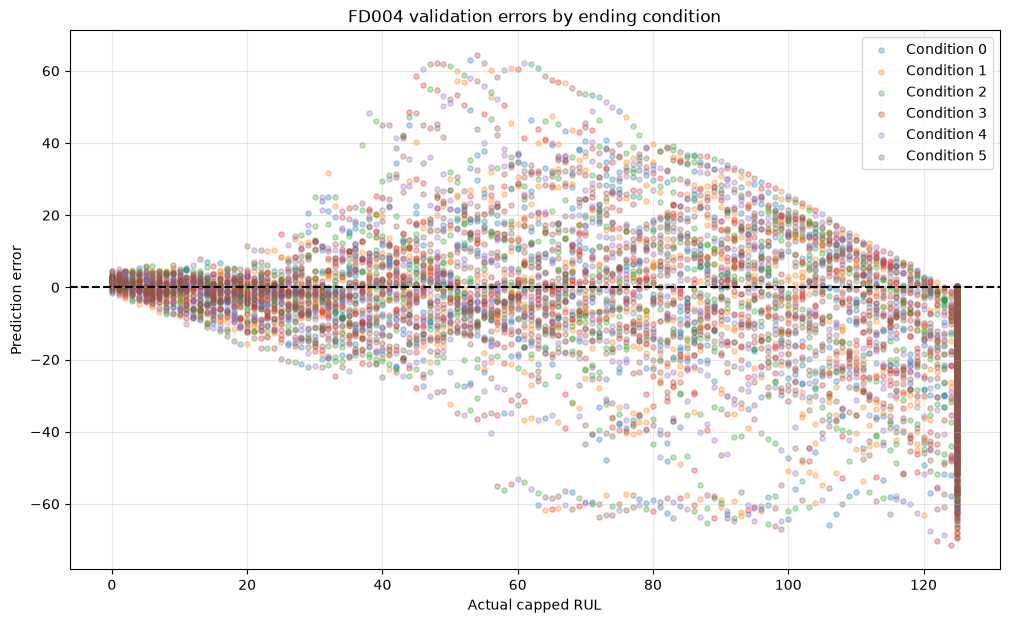

In [48]:
# ============================================================
# FD004 safety-aware experiment configuration
# ============================================================

SAFETY_CRITICAL_RUL = 30.0
"""RUL at or below which overprediction is more dangerous."""

SAFETY_OVERPREDICTION_WEIGHT = 2.0
"""Overprediction penalty outside the critical region."""

SAFETY_CRITICAL_OVERPREDICTION_WEIGHT = 5.0
"""Overprediction penalty inside the critical region."""


# Reset randomness before creating the new model and loaders.
set_random_seed(SEED)


# ============================================================
# Recreate loaders for an independent experiment
# ============================================================

(
    train_loader_fd004_safety,
    val_loader_fd004_safety,
    X_val_fd004_safety_tensor,
    y_val_fd004_safety_tensor,
) = create_loaders(
    X_train_fd004,
    y_train_fd004,
    X_val_fd004,
    y_val_fd004,
    batch_size=BATCH_SIZE,
    seed=SEED,
)
"""Fresh loaders for the safety-aware experiment."""


# ============================================================
# Create a completely fresh model
# ============================================================

model_fd004_safety = RULPredictor(
    input_size=X_train_fd004.shape[2],
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
)
"""New model; the baseline model remains unchanged."""


# ============================================================
# Train using the new safety-aware loss
# ============================================================

(
    model_fd004_safety,
    history_fd004_safety,
    best_epoch_fd004_safety,
    best_val_loss_fd004_safety,
) = train_safety_model(
    model=model_fd004_safety,
    train_loader=train_loader_fd004_safety,
    val_loader=val_loader_fd004_safety,
    device=DEVICE,
    epochs=MAXIMUM_EPOCHS,
    learning_rate=LEARNING_RATE,
    overprediction_weight=(
        SAFETY_OVERPREDICTION_WEIGHT
    ),
    critical_rul=SAFETY_CRITICAL_RUL,
    critical_overprediction_weight=(
        SAFETY_CRITICAL_OVERPREDICTION_WEIGHT
    ),
    patience=EARLY_STOPPING_PATIENCE,
)
"""Safety-aware trained model and best checkpoint information."""


# ============================================================
# Evaluate using ordinary MAE, MSE, and RMSE
# ============================================================

results_fd004_safety = evaluate_model(
    model_fd004_safety,
    X_val_fd004_safety_tensor,
    y_val_fd004,
    device=DEVICE,
)
"""Standard validation results for the safety-aware model."""


print()
print("FD004 safety-aware LSTM using:", DEVICE)
print("Best epoch:", best_epoch_fd004_safety)

print(
    "Best safety-aware validation loss:",
    f"{best_val_loss_fd004_safety:.2f}",
)

print(
    "Validation MAE:",
    f"{results_fd004_safety['mae']:.2f}",
)

print(
    "Validation MSE:",
    f"{results_fd004_safety['mse']:.2f}",
)

print(
    "Validation RMSE:",
    f"{results_fd004_safety['rmse']:.2f}",
)


# ============================================================
# Calculate critical-region safety metrics
# ============================================================

safety_metrics_fd004_new = calculate_safety_metrics(
    y_val_fd004,
    results_fd004_safety["predictions"],
    critical_rul=int(SAFETY_CRITICAL_RUL),
    severe_error_threshold=10,
)

print()
print("Safety-aware model: critical-region metrics")

for metric_name, metric_value in (
    safety_metrics_fd004_new.items()
):
    print(f"{metric_name}: {metric_value}")


# ============================================================
# Calculate metrics by ending operating condition
# ============================================================

val_sequence_metadata_safety = create_sequence_metadata(
    fd004_val_normalized,
    window=WINDOW,
)

assert (
    len(val_sequence_metadata_safety)
    == len(y_val_fd004)
    == len(results_fd004_safety["predictions"])
)

condition_metrics_fd004_safety = (
    calculate_condition_metrics(
        y_val_fd004,
        results_fd004_safety["predictions"],
        val_sequence_metadata_safety,
    )
)

print()
print(
    "Safety-aware validation metrics "
    "by ending condition:"
)

display(
    condition_metrics_fd004_safety
)


# ============================================================
# Plot the new experiment
# ============================================================

plot_training_history(
    history_fd004_safety
)

plot_errors_by_condition(
    y_val_fd004,
    results_fd004_safety["predictions"],
    val_sequence_metadata_safety,
)

#### Now we can clearly see that critical RUL range is not doing too much overprediction

In [49]:
baseline_safety_metrics = pd.Series(
    safety_metrics_fd004,
    name="Baseline",
)

new_safety_metrics = pd.Series(
    safety_metrics_fd004_new,
    name="Safety-aware",
)

safety_comparison = pd.concat(
    [
        baseline_safety_metrics,
        new_safety_metrics,
    ],
    axis=1,
)

display(safety_comparison)

,Baseline,Safety-aware
critical_rul_threshold,30.000000,30.000000
sequence_count,1550.000000,1550.000000
mae,4.530732,3.679379
rmse,5.888406,5.235185
mean_error,1.417077,-1.368195
overprediction_rate,0.659355,0.434194
mean_overprediction,4.510324,2.661468
maximum_overprediction,27.328629,24.983387
severe_overprediction_rate,0.043871,0.017419
